### Notebook 6: Maße der zentralen Tendenz und Streuung

#### 6.1 Maße der zentralen Tendenz
- Mittelwert, Median, Modus
- Vergleich bei symmetrischen vs. schiefen Verteilungen
- Beispiele mit Python

#### 6.2 Maße der Streuung
- Varianz, Standardabweichung, Variationskoeffizient
- Beispiele mit Python

#### 6.3 Erweiterte Streuungsmaße
- Schiefe (Skewness)
- Kurtosis (Wölbung)
- Beispiele mit Python

#### 6.4 Quantile und Lageparameter
- Quantile, Quartile, Interquartilsabstand (IQR)
- Robustheit gegenüber Ausreißern
- Beispiele mit Python

#### 6.5 Visualisierungen
- Histogramme, Boxplots, Violinplots
- Kernel Density Estimation (KDE)
- QQ-Plots (Vergleich mit theoretischen Verteilungen)

#### 6.6 Zusammenfassung & Anwendungsbezug
- Wann welches Maß sinnvoll ist
- Anwendungen in Data Science & ML


### 6.1 Maße der zentralen Tendenz

Die **Maße der zentralen Tendenz** beschreiben, wo der "Mittelpunkt" oder das typische Ergebnis einer Verteilung liegt.  
Die drei wichtigsten Maße sind **Mittelwert**, **Median** und **Modus**.

---

#### Mittelwert (arithmetisches Mittel)
Der Mittelwert ist die Summe aller Werte geteilt durch die Anzahl der Beobachtungen:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

- **Eigenschaft**: Nutzt alle Datenpunkte, aber empfindlich gegenüber Ausreißern.
- **Anwendung**: Durchschnittswerte in Physik (z. B. mittlere Geschwindigkeit), Biologie (mittlere Genexpressionswerte), Ökonomie (Durchschnittseinkommen).

---

#### Median
Der Median ist der Wert, der die Daten in zwei Hälften teilt:
- 50 % der Werte liegen **unterhalb**, 50 % **oberhalb**.
- Bei ungerader Anzahl Datenpunkte: mittlerer Wert nach Sortierung.
- Bei gerader Anzahl: Mittelwert der beiden mittleren Werte.

- **Eigenschaft**: Robust gegenüber Ausreißern.
- **Anwendung**: Typischer in der Statistik von Einkommen, da einige Extremwerte den Mittelwert stark verzerren können.

---

#### Modus
Der Modus ist der **häufigste Wert** in den Daten.

- **Eigenschaft**: Besonders nützlich für **diskrete Daten** oder kategorielle Merkmale.
- **Anwendung**: Häufigste Farbe in einem Bild, häufigste Diagnose in einer Patientengruppe.

---

#### Vergleich bei symmetrischen vs. schiefen Verteilungen
- **Symmetrische Verteilung** (z. B. Normalverteilung): Mittelwert ≈ Median ≈ Modus.
- **Rechts-schiefe Verteilung** (lange Ausläufer nach rechts, z. B. Einkommen):  
  $$ \text{Modus} < \text{Median} < \text{Mittelwert} $$
- **Links-schiefe Verteilung** (lange Ausläufer nach links):  
  $$ \text{Mittelwert} < \text{Median} < \text{Modus} $$

---

#### Beispiel aus der Physik: Schiefe in optischen Materialien
Beim **Streuverhalten von Licht** in verschiedenen Medien (z. B. Glas, Nebel, biologische Gewebe) können Intensitätsverteilungen beobachtet werden:
- In **homogenen Medien** (Glas) ist die Streuung symmetrisch → Mittelwert ≈ Median.
- In **heterogenen Medien** (Gewebe, Nebel) treten viele kleine Streuungen auf, aber wenige sehr starke Abweichungen → rechts-schiefe Verteilungen.  
  → Der Mittelwert liegt deutlich über dem Median, da seltene, aber starke Streuungen die Statistik verzerren.

---

#### Mini-Beispiel (Python)


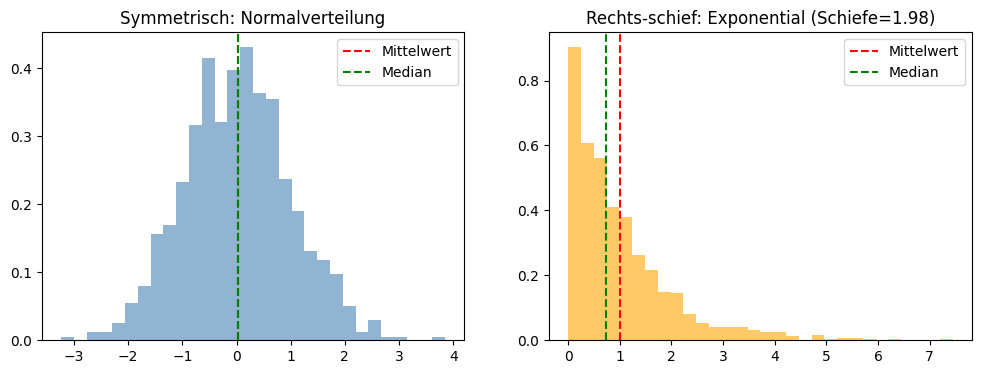

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# Simulation: symmetrische Normalverteilung & rechts-schiefe Exponentialverteilung
np.random.seed(42)
data_normal = np.random.normal(loc=0, scale=1, size=1000)
data_skewed = np.random.exponential(scale=1, size=1000)

fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Normalverteilung
axs[0].hist(data_normal, bins=30, density=True, alpha=0.6, color="steelblue")
axs[0].set_title("Symmetrisch: Normalverteilung")
axs[0].axvline(np.mean(data_normal), color='r', linestyle='--', label="Mittelwert")
axs[0].axvline(np.median(data_normal), color='g', linestyle='--', label="Median")
axs[0].legend()

# Schiefe Verteilung
axs[1].hist(data_skewed, bins=30, density=True, alpha=0.6, color="orange")
axs[1].set_title(f"Rechts-schief: Exponential (Schiefe={skew(data_skewed):.2f})")
axs[1].axvline(np.mean(data_skewed), color='r', linestyle='--', label="Mittelwert")
axs[1].axvline(np.median(data_skewed), color='g', linestyle='--', label="Median")
axs[1].legend()

plt.show()

### 6.2 Maße der Streuung

Während die Maße der zentralen Tendenz (Mittelwert, Median, Modus) die **Lage** einer Verteilung beschreiben, geben die **Maße der Streuung** Auskunft darüber, wie stark die Datenwerte um diesen Mittelpunkt schwanken.  

---

#### Varianz
Die Varianz misst die mittlere quadratische Abweichung der Werte vom Mittelwert:

$$
\text{Var}(X) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2
$$

- Einheit: Quadrat der ursprünglichen Daten (z. B. $m^2$ statt $m$).  
- **Interpretation**: Hohe Varianz bedeutet, dass die Daten stark streuen.  

---

#### Standardabweichung
Die Standardabweichung ist die Wurzel der Varianz:

$$
\sigma = \sqrt{\text{Var}(X)}
$$

- Einheit: gleiche Einheit wie die Daten selbst.  
- Sehr gebräuchlich in Natur- und Ingenieurwissenschaften.  

---

#### Variationskoeffizient (CV)
Der Variationskoeffizient ist ein **normiertes Maß der Streuung**:

$$
CV = \frac{\sigma}{\bar{x}}
$$

- Dimensionslos, daher nützlich zum Vergleich unterschiedlicher Größenordnungen.  
- Anwendung: Qualitätskontrolle, Biologie (Variabilität von Wachstumsraten), Ökonomie.  

---

#### Schiefe und Kurtosis (Ausblick)
Neben Varianz und Standardabweichung beschreiben **höhere Momente** die Form der Verteilung:
- **Schiefe** = Asymmetrie einer Verteilung.  
- **Kurtosis** = "Spitzigkeit" oder wie stark die Verteilung Ausreißer betont.  

---

#### Beispiel aus der Physik: Laserstrahlen in unterschiedlichen Medien
- Ein **Laserstrahl in Vakuum** zeigt praktisch keine Streuung → Standardabweichung nahe 0.  
- In einem **Turbulenz-Medium (z. B. warme Luft oder Plasma)** streut der Strahl stark, Varianz und Standardabweichung steigen deutlich.  
- Der **Variationskoeffizient** ist nützlich, um die relative Strahlstabilität zu vergleichen, wenn verschiedene Wellenlängen oder Intensitäten untersucht werden.

---

#### Mini-Beispiel (Python)



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
import ipywidgets as widgets
from IPython.display import display

def plot_skewnorm(a=0, loc=0, scale=1):
    x = np.linspace(-10, 10, 1000)
    pdf = skewnorm.pdf(x, a, loc, scale)

    # Erwartungswert, Median, Varianz
    mean = skewnorm.mean(a, loc, scale)
    median = skewnorm.median(a, loc, scale)
    var = skewnorm.var(a, loc, scale)
    skew = skewnorm.stats(a, loc, scale, moments="s")
    kurt = skewnorm.stats(a, loc, scale, moments="k")

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(x, pdf, label="PDF", color="steelblue")
    plt.axvline(mean, color="red", linestyle="--", label=f"Mittelwert = {mean:.2f}")
    plt.axvline(median, color="green", linestyle="--", label=f"Median = {median:.2f}")
    plt.title(f"Skew-Normal-Verteilung (a={a}, loc={loc}, scale={scale})")
    plt.xlabel("x")
    plt.ylabel("Dichte")
    plt.legend()

    # Textausgabe
    plt.figtext(0.15, -0.1, f"Varianz = {var:.2f} | Schiefe = {skew:.2f} | Kurtosis = {kurt:.2f}")
    plt.show()

# Interaktive Steuerung
widgets.interact(
    plot_skewnorm,
    a=widgets.FloatSlider(value=0, min=-10, max=10, step=0.5, description="Schiefe (a)"),
    loc=widgets.FloatSlider(value=0, min=-5, max=5, step=0.5, description="Lage (loc)"),
    scale=widgets.FloatSlider(value=1, min=0.5, max=5, step=0.5, description="Skala (scale)")
)


interactive(children=(FloatSlider(value=0.0, description='Schiefe (a)', max=10.0, min=-10.0, step=0.5), FloatS…

<function __main__.plot_skewnorm(a=0, loc=0, scale=1)>

#### 6.4 Quantile und Lageparameter

- **Definitionen**:  
  - **Quantil**: Wert, der eine Verteilung in Anteile teilt. Das $q$-Quantil $x_q$ erfüllt $P(X \le x_q) = q$.  
  - **Quartile**: Spezielle Quantile, die die Daten in vier gleich große Teile teilen:  
    - $Q_1$ (25%-Quantil), $Q_2$ (Median, 50%-Quantil), $Q_3$ (75%-Quantil)  
  - **Interquartilsabstand (IQR)**: Maß der Streuung zwischen dem oberen und unteren Quartil:  
    $$
    \text{IQR} = Q_3 - Q_1
    $$
  - **Robustheit**: Median und IQR sind weniger empfindlich gegenüber Ausreißern als Mittelwert und Standardabweichung.

- **Anwendung in Statistik und Data Science**:
  - **Robuste Lage- und Streumaße**: Median und IQR erfassen zentrale Tendenz und Streuung ohne Verzerrung durch Extremwerte.
  - **Feature Engineering in Machine Learning**:  
    - Robust Scaling: Transformation von Features unter Verwendung von Median und IQR statt Mittelwert und Standardabweichung.  
    - Identifikation von Ausreißern, z. B. durch Boxplots oder Violinplots.
  - **Explorative Datenanalyse (EDA)**: Visualisierung der Verteilung, Identifikation ungewöhnlicher Werte und Vergleich von Gruppen.
  - **Praxisbeispiele**:
    - Finanzdaten: Renditen von Aktien oder Kryptowährungen oft mit Extremwerten. Median und IQR geben ein robustes Bild der zentralen Tendenz.  
    - Qualitätskontrolle: Produktionsmetriken (z. B. Abmessungen, Toleranzen) können Ausreißer enthalten; IQR hilft, typische Bereiche zu definieren.

- **Visualisierung**:
  - Boxplots zeigen Median, Quartile und Whiskers (oft $1.5 \times \text{IQR}$), Ausreißer werden als Punkte markiert.
  - Violinplots kombinieren Dichte-Information mit Quartilen.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Zufallsdaten
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)
data[::15] += 25  # einige Ausreißer hinzufügen

# Fixe x-Achse
x_min = data.min() - 10
x_max = data.max() + 10

def plot_box_line(show_median, show_quartiles, show_iqr, show_whiskers, show_outliers):
    plt.figure(figsize=(12,2))
    
    # Daten als Linie
    y_pos = np.zeros_like(data)
    plt.scatter(data, y_pos, color='blue', alpha=0.6, s=20, label='Messwerte')
    
    # Berechnungen
    Q1 = np.percentile(data, 25)
    Q2 = np.percentile(data, 50)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    whisker_low = Q1 - 1.5*IQR
    whisker_high = Q3 + 1.5*IQR
    
    # Median
    if show_median:
        plt.axvline(Q2, color='red', linestyle='-', label=f"Median = {Q2:.2f}")
    
    # Quartile
    if show_quartiles:
        plt.axvline(Q1, color='green', linestyle='--', label=f"Q1 = {Q1:.2f}")
        plt.axvline(Q3, color='green', linestyle='--', label=f"Q3 = {Q3:.2f}")
    
    # IQR als Band
    if show_iqr:
        plt.fill_betweenx([-0.1, 0.1], Q1, Q3, color='green', alpha=0.1, label='IQR')
    
    # Whiskers
    if show_whiskers:
        plt.axvline(whisker_low, color='orange', linestyle=':', label=f"Whisker Low = {whisker_low:.2f}")
        plt.axvline(whisker_high, color='orange', linestyle=':', label=f"Whisker High = {whisker_high:.2f}")
    
    # Ausreißer
    if show_outliers:
        outliers = data[(data < whisker_low) | (data > whisker_high)]
        plt.scatter(outliers, np.zeros_like(outliers), color='red', s=50, label='Ausreißer', zorder=5)
    
    # Achse, Titel
    plt.xlim(x_min, x_max)
    plt.yticks([])
    plt.xlabel("Messwerte")
    plt.title("Interaktive Boxplot-Analyse (Linienversion)")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Interaktive Widgets
widgets.interact(
    plot_box_line,
    show_median=widgets.Checkbox(value=True, description="Median"),
    show_quartiles=widgets.Checkbox(value=False, description="Quartile"),
    show_iqr=widgets.Checkbox(value=False, description="IQR"),
    show_whiskers=widgets.Checkbox(value=False, description="Whiskers"),
    show_outliers=widgets.Checkbox(value=True, description="Ausreißer")
)


interactive(children=(Checkbox(value=True, description='Median'), Checkbox(value=False, description='Quartile'…

<function __main__.plot_box_line(show_median, show_quartiles, show_iqr, show_whiskers, show_outliers)>

### 6.5 Visualisierungen von Verteilungen

Um die Verteilung von Daten anschaulich darzustellen, werden in der Datenanalyse verschiedene Visualisierungstechniken eingesetzt. Jede hat ihre Stärken und eignet sich für unterschiedliche Fragestellungen.

---

#### 1. Histogramm
- **Aufbau:**  
  - Die Daten werden in **Intervalle (Bins)** unterteilt.  
  - Die Höhe jedes Balkens zeigt die **Häufigkeit** oder **relative Häufigkeit** der Daten in diesem Intervall.  
- **Mathematischer Hintergrund:**  
  Für n Datenpunkte $x_1, \dots, x_n$ und Bin-Breite $h$:
  $$
  f_{\text{hist}}(x) = \frac{\text{Anzahl der Punkte im Bin}}{n \cdot h}
  $$
- **Parameter:**  
  - `bins`: Anzahl oder Grenzen der Intervalle; Faustregeln: $\sqrt{n}$, Sturges, Freedman–Diaconis.  
  - `density=True/False`: Normierung auf Dichte oder absolute Häufigkeiten.
- **Verwendung:**  
  - Schnelle Übersicht über die **Verteilung** der Daten.  
  - Erkennen von **Schiefe, Modus, Mehrgipfligkeit** oder Ausreißern.  

---

#### 2. Boxplot (Kastenplot)
- **Aufbau:**  
  - Kasten zeigt den **Interquartilsbereich (IQR)** von $Q_1$ bis $Q_3$.  
  - Linie im Kasten: **Median $Q_2$**.  
  - „Whiskers“ erstrecken sich typischerweise bis zu $1.5 \times \text{IQR}$ über $Q_3$ bzw. unter $Q_1$.  
  - Werte außerhalb der Whiskers werden als **Ausreißer** markiert.  
- **Mathematischer Hintergrund:**  
  - $IQR = Q_3 - Q_1$  
  - Whiskers: $[Q_1 - 1.5\cdot IQR, Q_3 + 1.5\cdot IQR]$  
- **Verwendung:**  
  - Visualisierung der **zentralen Tendenz** und **Streuung**.  
  - Identifikation von **Ausreißern**.  
  - Vergleich von **Gruppenverteilungen**.

---

#### 3. Violinplot
- **Aufbau:**  
  - Kombination aus **Boxplot** und **Dichteplot**.  
  - Der „Körper“ zeigt die **geschätzte Dichte der Daten** (vertikale Symmetrie).  
  - Innen kann ein Boxplot die **Quartile, Median und Ausreißer** anzeigen.  
- **Verwendung:**  
  - Vergleich von **Verteilungen zwischen Gruppen**.  
  - Darstellung von **Mehrgipfligkeit** und **Form der Verteilung**.

---

#### 4. Kernel Density Estimation (KDE)
- **Aufbau:**  
  - KDE ist eine **nichtparametrische Methode**, um die Wahrscheinlichkeitsdichte einer Zufallsvariablen zu schätzen.  
- **Schritt-für-Schritt:**  
  1. Jeder Datenpunkt wird durch eine **Glockenkurve (Kernel)** repräsentiert, typischerweise Normalverteilung.  
  2. Alle einzelnen Kurven werden **überlagert und summiert**, wodurch eine glatte Dichtefunktion entsteht.  
  3. Die Höhe der Kurve an einem Punkt $x$ entspricht der **geschätzten Dichte $\hat{f}(x)$**.
- **Formel:**  
  $$
  \hat{f}(x) = \frac{1}{n h} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)
  $$
  - $K$ = Kernel-Funktion (z. B. Gauß)  
  - $h$ = Bandbreite (Glättungsparameter)  
- **Verwendung:**  
  - Glatte Darstellung der **Verteilung**, besonders bei kleinen Datensätzen oder unregelmäßiger Verteilung.  
  - Vergleich der **Form von Verteilungen** zwischen Gruppen.  
  - Erkennung von **Mehrgipfligkeit** oder lokalen Maxima, die Histogramme durch Wahl der Bins verschleiern könnten.

---

#### 5. QQ-Plot (Quantile-Quantile-Plot)
- **Aufbau:**  
  - Vergleicht die **Quantile einer empirischen Verteilung** mit den Quantilen einer **theoretischen Verteilung** (z. B. Normalverteilung).  
  - Punkte liegen idealerweise auf der Diagonalen, wenn die Daten der theoretischen Verteilung folgen.  
- **Verwendung:**  
  - Überprüfung, ob die Daten **normalverteilt** oder einer anderen theoretischen Verteilung entsprechen.  
  - Sichtbare Abweichungen:  
    - **S-Kurve** → leichte Schiefe  
    - **Enden abweichend** → fette oder dünne Schwanzverteilungen (Kurtosis)

---

#### 6. Vergleich der Plots

| Plot            | Vorteil                                           | Nachteil / Einschränkung                     |
|-----------------|--------------------------------------------------|---------------------------------------------|
| Histogramm       | Intuitiv, einfache Implementierung             | Bin-Größe kann Verteilung verzerren         |
| Boxplot          | Zeigt Median, Quartile, Ausreißer              | Keine Information über Dichte oder Form    |
| Violinplot       | Zeigt Form, Quartile, Ausreißer in einem Plot  | Kann bei wenigen Datenpunkten irreführend sein |
| KDE              | Glatte Dichte, gut für Vergleich                | Bandbreite $h$ beeinflusst Glätte stark; nicht für diskrete Daten ideal |
| QQ-Plot          | Überprüfung theoretischer Verteilungen         | Kein direktes Maß für Häufigkeiten; nur visuell interpretierbar |

---

**Praxisbeispiele in Data Science / Statistik:**
- **Histogramme**: Feature Exploration, erste Übersicht über Datendistribution.  
- **Boxplots & Violinplots**: Gruppenvergleiche, Identifikation von Ausreißern, Feature Engineering.  
- **KDE**: Analyse der Form von Features, Erkennung von Mehrgipfligkeit, Anomalie-Erkennung.  
- **QQ-Plots**: Prüfung der Normalität eines Features, wichtig für t-Tests, ANOVA, Standardisierung.


## Python Beispiele

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Standard-Parameter
np.random.seed(42)
n_samples = 500

def plot_histogram(mu=0, sigma=1, show_recommended_bins=True, bins_manual=20):
    # Zufallsdaten
    data = np.random.normal(mu, sigma, n_samples)
    
    # Empfohlene Bin-Anzahl: Sturges' Rule
    recommended_bins = int(np.ceil(np.log2(n_samples) + 1))
    bins = recommended_bins if show_recommended_bins else bins_manual
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.hist(data, bins=bins, color='skyblue', edgecolor='black', alpha=0.7, density=True)
    
    # Dichtekurve der Normalverteilung zur Orientierung
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    plt.plot(x, (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2)), 
             color='red', lw=2, label='True PDF')
    
    plt.title(f"Histogramm (n={n_samples}, bins={bins})", fontsize=14)
    plt.xlabel("Wert")
    plt.ylabel("Dichte")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Interaktives Widget
widgets.interact(
    plot_histogram,
    mu=widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description='Mittelwert μ'),
    sigma=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Std σ'),
    show_recommended_bins=widgets.Checkbox(value=True, description='Empfohlene Bins'),
    bins_manual=widgets.IntSlider(value=20, min=5, max=100, step=1, description='Manuelle Bins')
)


interactive(children=(FloatSlider(value=0.0, description='Mittelwert μ', max=5.0, min=-5.0), FloatSlider(value…

<function __main__.plot_histogram(mu=0, sigma=1, show_recommended_bins=True, bins_manual=20)>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
from IPython.display import display, clear_output

# Function to update KDE plot for a given step
def kde_step(step, mu=0, sigma=1, n_samples=30, bandwidth=0.5):
    np.random.seed(42)
    data = np.random.normal(mu, sigma, n_samples)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    
    # Precompute kernels
    kernels = [np.exp(-(x - xi)**2/(2*bandwidth**2))/(bandwidth*np.sqrt(2*np.pi)) for xi in data]
    
    cumulative = np.zeros_like(x)
    
    plt.figure(figsize=(10,5))
    
    # True PDF
    plt.plot(x, (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2)),
             color='red', lw=2, label='True PDF')
    
    # Previous kernels in grey
    for i in range(step):
        cumulative += kernels[i]/n_samples
        plt.plot(x, kernels[i]/n_samples, color='grey', alpha=0.5)
    
    if step < n_samples:
        # Current sample kernel in green
        cumulative += kernels[step]/n_samples
        plt.plot(x, kernels[step]/n_samples, color='green', lw=2, label='Current Kernel')
        # Current sample marker
        plt.scatter(data[step], 0, color='green', s=100, zorder=5, label='Current Sample')
    
    # Cumulative KDE
    plt.plot(x, cumulative, color='blue', lw=2, label='KDE')
    
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.title(f"KDE Animation Step {step+1}/{n_samples}")
    plt.grid(linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Interactive slider
interact(
    kde_step,
    step=IntSlider(min=0, max=50, step=1, value=0, description='Step'),
    mu=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ'),
    sigma=FloatSlider(value=1, min=0.1, max=3, step=0.1, description='σ'),
    n_samples=IntSlider(value=30, min=5, max=50, step=1, description='Samples'),
    bandwidth=FloatSlider(value=0.5, min=0.1, max=2, step=0.05, description='Bandwidth h')
)


interactive(children=(IntSlider(value=0, description='Step', max=50), FloatSlider(value=0.0, description='μ', …

<function __main__.kde_step(step, mu=0, sigma=1, n_samples=30, bandwidth=0.5)>

### Violin Plot (Geige-Plot)

Ein **Violinplot** ist eine Erweiterung des Boxplots, das die **Verteilung einer numerischen Variable** visuell darstellt. Es kombiniert die Merkmale eines Boxplots mit einer **geschätzten Dichtefunktion (KDE)**.

---

#### Aufbau

- **Körper der Violine**: zeigt die **KDE** (Kernel Density Estimate) der Daten.
  - Breite der Violine an einem Punkt entspricht der **Dichte der Werte**.
  - Form gibt Aufschluss über **Mehrgipfligkeit, Schiefe und Modalität**.
- **Innere Linie / Marker** (optional):
  - **Median** (zentrale Linie)
  - **Quartile** (Q1, Q3)
  - **Ausreißer** (Punkte außerhalb typischer Bereiche)
- **Symmetrie**: Violinplots sind meist vertikal gespiegelt, sodass die Verteilung auf beiden Seiten angezeigt wird.

---

#### Interpretation

1. **Form und Breite**:
   - Breite an einer Stelle zeigt, wie viele Datenpunkte in diesem Wertebereich liegen.
   - Mehrgipfligkeit (multiple peaks) wird sofort sichtbar.
2. **Median und Quartile**:
   - Median zeigt den zentralen Tendenzwert.
   - Quartile zeigen den interquartilen Bereich, ähnlich wie im Boxplot.
3. **Ausreißer**:
   - Einzelne Punkte außerhalb der "normalen" Dichte können als Ausreißer markiert werden.

---

#### Typische Anwendungen in Data Science

- **Vergleich von Gruppen**: z. B. Verteilung eines Features in verschiedenen Klassen.
- **Explorative Datenanalyse (EDA)**: Erkennen von Mehrgipfligkeit, Schiefe, und Verteilungsform.
- **Feature Engineering**: Analyse, ob Transformationen nötig sind (z. B. Log-Transformation bei stark schiefen Daten).

---

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets

def plot_violin_distribution(dist_type='Normal', mu1=0, sigma1=1, mu2=3, sigma2=1, weight2=0.5):
    np.random.seed(42)
    n = 200
    
    if dist_type == 'Normal':
        data = np.random.normal(mu1, sigma1, n)
    elif dist_type == 'GMM':
        n2 = int(n * weight2)
        n1 = n - n2
        data = np.concatenate([
            np.random.normal(mu1, sigma1, n1),
            np.random.normal(mu2, sigma2, n2)
        ])
    data = pd.DataFrame({'Werte': data})

    plt.figure(figsize=(7,9))
    
    # Violinplot
    ax = sns.violinplot(
        y='Werte',
        data=data,
        inner=None,  
        color='skyblue',
        linewidth=1.5,
        width=0.7
    )
    
    # Boxplot inside violin
    sns.boxplot(
        y='Werte',
        data=data,
        whis=1.5,
        width=0.2,
        showcaps=True,
        boxprops={'facecolor':'none','edgecolor':'black','linewidth':2},
        medianprops={'color':'red','linewidth':2},
        whiskerprops={'color':'orange','linewidth':2},
        capprops={'color':'orange','linewidth':2},
        flierprops={'marker':'o','markerfacecolor':'red','markersize':6,'linestyle':'none'}
    )
    
    # Stripplot für alle Punkte (grün entlang x-Achse)
    x_positions = np.linspace(-0.0, 0.0, len(data))
    plt.scatter(x_positions, data['Werte'], color='green', alpha=0.5, s=15, label='Samples (x-Achse)')
    

    
    # Statistische Kennzahlen
    median = np.median(data['Werte'])
    mean = np.mean(data['Werte'])
    Q1 = np.percentile(data['Werte'], 25)
    Q3 = np.percentile(data['Werte'], 75)
    IQR = Q3 - Q1
    whisker_low = Q1 - 1.5*IQR
    whisker_high = Q3 + 1.5*IQR
    # Ausreißer bestimmen
    outliers = data[(data['Werte'] < whisker_low) | (data['Werte'] > whisker_high)]

    # Ausreißer als rote Punkte markieren
    plt.scatter(
        np.zeros_like(outliers['Werte']).ravel(),  # 1D-Array
        outliers['Werte'].values.ravel(),          # 1D-Array
        color='red',
        s=40,
        label='Ausreißer',
        zorder=10
    )
    
    # Labels zeichnen
    plt.text(0.25, median, f'Median={median:.2f}', color='red', fontsize=10)
    plt.text(0.25, mean, f'Mean={mean:.2f}', color='blue', fontsize=10)
    plt.text(0.25, Q1, f'Q1={Q1:.2f}', color='green', fontsize=10)
    plt.text(0.25, Q3, f'Q3={Q3:.2f}', color='green', fontsize=10)
    
    if dist_type == 'GMM':
        plt.title(f"Violinplot + Boxplot: 2-Komponenten GMM\nμ1={mu1}, σ1={sigma1}, μ2={mu2}, σ2={sigma2}, w2={weight2}", fontsize=14, fontweight='bold')
    else:
        plt.title(f"Violinplot + Boxplot: Normalverteilung\nμ={mu1}, σ={sigma1}", fontsize=14, fontweight='bold')
    
    plt.ylabel("Werte", fontsize=12)
    plt.xticks([])
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

widgets.interact(
    plot_violin_distribution,
    dist_type=widgets.Dropdown(options=['Normal','GMM'], value='Normal', description='Distribution'),
    mu1=widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ1'),
    sigma1=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ1'),
    mu2=widgets.FloatSlider(value=3, min=-5, max=5, step=0.1, description='μ2 (GMM)'),
    sigma2=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ2 (GMM)'),
    weight2=widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description='Weight 2')
)


interactive(children=(Dropdown(description='Distribution', options=('Normal', 'GMM'), value='Normal'), FloatSl…

<function __main__.plot_violin_distribution(dist_type='Normal', mu1=0, sigma1=1, mu2=3, sigma2=1, weight2=0.5)>

#### 5. QQ-Plot (Quantile-Quantile-Plot) & Dichtevergleich

- **Aufbau eines QQ-Plots:**  
  - Vergleicht die **Quantile einer empirischen Datenverteilung** $X$ mit den Quantilen einer **theoretischen Verteilung** $Y$ (z. B. Normalverteilung).  
  - Für $n$ Beobachtungen $x_1 \le x_2 \le ... \le x_n$ werden die **empirischen Quantile** mit den **theoretischen Quantilen** der gewählten Verteilung bei denselben Wahrscheinlichkeiten aufgetragen:  
    $$
    q_i^{\text{emp}} = x_i, \quad q_i^{\text{theor}} = F_Y^{-1}\Big(\frac{i-0.5}{n}\Big), \quad i=1,...,n
    $$  
  - Liegen die Punkte **nahe der Diagonalen $y=x$**, folgt die empirische Verteilung der theoretischen.

- **Interpretation:**  
  - **S-Kurve:** weist auf **Schiefe** der Daten hin.  
  - **Abweichungen an den Enden:** zeigen fette oder dünne **Schwänze** (Kurtosis).  
  - **Gleichmäßige Abweichungen:** deuten auf systematische Unterschiede in der Verteilungsform hin.

- **Dichtevergleich:**  
  - Zusätzlich zum QQ-Plot kann ein **Histogramm der Stichprobe** überlagert mit der **PDF der theoretischen Verteilung** visualisiert werden:  
    $$
    f_X(x) \approx \frac{\text{Häufigkeit in Bin}}{n \cdot \text{Bin-Breite}}, \quad 
    f_Y(x) = \text{theoretische Dichte bei } x
    $$  
  - Quartile können sowohl für die empirische als auch die theoretische Verteilung markiert werden, um zentrale Tendenz und Streuung direkt zu vergleichen.

- **Verwendung in Statistik & Data Science:**  
  - Überprüfung der **Normalität** eines Features (wichtig z. B. für t-Tests, ANOVA oder Standardisierung).  
  - Vergleich der Stichprobe mit **beliebigen theoretischen Verteilungen** (Normal, t, Exponential, etc.).  
  - Erkennung von **Ausreißern**, Schiefe und unterschiedlichen Schwänzen.  

- **Beispiel:**  
  - Wenn die Daten normalverteilt sind, liegen die Punkte auf der Diagonalen.  
  - Abweichungen vom Diagonalverlauf zeigen, dass die Daten **nicht normal** verteilt sind oder **lokale Unterschiede** in der Dichte aufweisen.  
  - Durch Veränderung der theoretischen Verteilung (z. B. t-Verteilung mit kleinen Freiheitsgraden oder Exponentialverteilung) können **S-Kurven** und **Abweichungen an den Enden** anschaulich untersucht werden.

- **Mathematische Berechnung der theoretischen Quantile:**  
  - Für Normalverteilung: $q_i^{\text{theor}} = \Phi^{-1}\left(\frac{i-0.5}{n}\right)$, wobei $\Phi^{-1}$ die inverse Standardnormalverteilung ist.  
  - Für t-Verteilung mit $df$ Freiheitsgraden: $q_i^{\text{theor}} = t_{df}^{-1}\left(\frac{i-0.5}{n}\right)$  
  - Für Exponentialverteilung mit Rate $\lambda$: $q_i^{\text{theor}} = F_{\text{Exp}}^{-1}\left(\frac{i-0.5}{n}\right) = -\frac{1}{\lambda}\ln\left(1 - \frac{i-0.5}{n}\right)$

- **Praxisbeispiele in Data Science:**  
  - Validierung von Features vor Standardisierung oder Transformation.  
  - Analyse von Residuen in Regressionsmodellen.  
  - Identifikation von Extremwerten und Formabweichungen in empirischen Datensätzen.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t, expon
import ipywidgets as widgets
from IPython.display import display

# Stichprobe generieren
np.random.seed(42)
n = 100
sample = np.random.normal(loc=0, scale=1, size=n)

def qq_density_plot(dist_name='Normal', mu=0, sigma=1, df=5, scale=1):
    x_sorted = np.sort(sample)
    n = len(x_sorted)
    probs = (np.arange(1, n+1) - 0.5) / n

    # Theoretische Quantile & PDF
    if dist_name == 'Normal':
        theoretical_q = norm.ppf(probs, loc=mu, scale=sigma)
        pdf_x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
        pdf_y = norm.pdf(pdf_x, loc=mu, scale=sigma)
        q_theory = norm.ppf([0.25, 0.5, 0.75], loc=mu, scale=sigma)
    elif dist_name == 't':
        theoretical_q = t.ppf(probs, df=df)
        pdf_x = np.linspace(-4, 4, 500)
        pdf_y = t.pdf(pdf_x, df=df)
        q_theory = t.ppf([0.25, 0.5, 0.75], df=df)
    elif dist_name == 'Exponential':
        theoretical_q = expon.ppf(probs, scale=scale)
        pdf_x = np.linspace(0, 8*scale, 500)
        pdf_y = expon.pdf(pdf_x, scale=scale)
        q_theory = expon.ppf([0.25, 0.5, 0.75], scale=scale)
    else:
        raise ValueError("Distribution not implemented")

    # Quartile empirisch
    q_empirical = np.percentile(x_sorted, [25,50,75])

    fig, axs = plt.subplots(1,2, figsize=(14,6))

    # --- QQ-Plot ---
    axs[0].scatter(theoretical_q, x_sorted, color='blue', alpha=0.6, label='Quantile Punkte')
    axs[0].plot(theoretical_q, theoretical_q, color='red', linestyle='--', label='y=x')
    
    # Rote Punkte für theoretische Quartile + Text
    for i, q in enumerate(q_theory):
        axs[0].scatter(q, q, color='red', s=80)
        axs[0].text(q, q, f"Q{i+1}", color='red', fontsize=10, verticalalignment='bottom', horizontalalignment='right')

    # Grüne Punkte für empirische Quartile
    axs[0].scatter(q_theory, q_empirical, color='green', s=100, label='Empirische Quartile')
    
    axs[0].set_title(f"QQ-Plot: Sample vs. {dist_name}")
    axs[0].set_xlabel("Theoretische Quantile")
    axs[0].set_ylabel("Empirische Quantile")
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # --- Dichtevergleich ---
    axs[1].hist(sample, bins=15, density=True, alpha=0.5, color='blue', label='Empirische Dichte')
    axs[1].plot(pdf_x, pdf_y, color='red', linestyle='--', label=f'{dist_name} PDF')

    # Rote Punkte auf theoretischer PDF
    pdf_q_y = norm.pdf(q_theory, loc=mu, scale=sigma) if dist_name=='Normal' else \
              t.pdf(q_theory, df=df) if dist_name=='t' else \
              expon.pdf(q_theory, scale=scale)
    axs[1].scatter(q_theory, pdf_q_y, color='red', s=80)
    for i, (qx, qy) in enumerate(zip(q_theory, pdf_q_y)):
        axs[1].text(qx, qy, f"Q{i+1}", color='red', fontsize=10, verticalalignment='bottom', horizontalalignment='center')

    # Grüne Punkte für empirische Quartile in PDF
    hist_vals = np.interp(q_empirical, pdf_x, pdf_y)
    axs[1].scatter(q_empirical, hist_vals, color='green', s=100, label='Empirische Quartile')
    
    axs[1].set_title(f"Empirische vs. Theoretische Dichte ({dist_name})")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("Dichte")
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.5)

    plt.show()

widgets.interact(
    qq_density_plot,
    dist_name=widgets.Dropdown(options=['Normal','t','Exponential'], value='Normal', description='Theor. Dist'),
    mu=widgets.FloatSlider(min=-5, max=5, value=0, step=0.1, description='Mu (Normal)'),
    sigma=widgets.FloatSlider(min=0.1, max=5, value=1, step=0.1, description='Sigma (Normal)'),
    df=widgets.IntSlider(min=1, max=30, value=5, description='df (t)'),
    scale=widgets.FloatSlider(min=0.1, max=5, value=1, step=0.1, description='Scale (Exp)')
)


interactive(children=(Dropdown(description='Theor. Dist', options=('Normal', 't', 'Exponential'), value='Norma…

<function __main__.qq_density_plot(dist_name='Normal', mu=0, sigma=1, df=5, scale=1)>